# 04 - Benchmark: DDM vs. Baselines

**Summary.** Trains the five models (Bigram, 3-gram, DDM, DDM-Ablation,
Transformer) on the same data with the same budget and produces the
comparison table (test PPL, parameter count, wall time, position-bucket
PPL) requested by the experiment plan in `model_info/2.md`. Results are
written to `checkpoints/benchmark_results.md`.

The position-bucket PPL shows whether a model actually *uses* long context:
if PPL on late positions (e.g. 50-200) is lower than on early positions
(0-10), the longer history helps. Set `DDM_SMOKE=1` for a quick smoke run.

In [1]:
# --- repo root bootstrap: lets the notebook run from any working directory ---
import os, sys
from pathlib import Path

def _find_root() -> Path:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return here

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
SMOKE = os.environ.get("DDM_SMOKE", "0") == "1"
print("repo root:", ROOT, "| DDM_SMOKE:", SMOKE)


repo root: C:\Users\yasir\Desktop\ammar | DDM_SMOKE: True


In [2]:
from pathlib import Path

from ddm.config import DDMConfig
from ddm.train import run_training, format_results_table
from ddm.models import count_parameters, build_model
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
CONFIGS = {
    "A - Bigram":     "configs/bigram.yaml",
    "B - 3-gram":     "configs/ngram.yaml",
    "C - DDM":        "configs/ddm_base.yaml",
    "D - DDM Ablation": "configs/ddm_ablation.yaml",
    "E - Transformer":  "configs/transformer_baseline.yaml",
}

In [4]:
configs = {name: DDMConfig.from_yaml(path) for name, path in CONFIGS.items()}
for cfg in configs.values():
    if SMOKE:
        cfg.max_steps = 3
        cfg.max_blocks = 64
        cfg.epochs = 1
        cfg.seeds = cfg.seeds[:1]

In [5]:
all_results = {}
for name, cfg in configs.items():
    print("\n################", name, "################")
    n_params = count_parameters(build_model(cfg))
    all_results[name] = run_training(cfg)
    all_results[name]["n_params"] = n_params


################ A - Bigram ################


[train] device: cuda
[data] loading wikitext/wikitext-2-raw-v1 (cache: hf_cache)...


[data] script-based loading failed (HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.); switching to local parquet fallback...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


[data] blocks -> train: (64, 128), val: (64, 128), test: (64, 128)
[train] vocab_size: 50257

=== seed 0 ===


...

[data] script-based loading failed (HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.); switching to local parquet fallback...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


[data] blocks -> train: (64, 128), val: (64, 128), test: (64, 128)
[train] vocab_size: 50257

=== seed 0 ===
[train] transformer parameters: 13,329,233
--- epoch 1/1 ---


[train] epoch 1: loss 11.0021, val PPL 56685.00


[train] test PPL: 55972.15 (2.5s)


### Comparison table (test set)

In [6]:
def summary_table(all_results):
    header = ("| Model | Params | Test PPL (mean±std) | PPL(0-10) | PPL(50-200) | Time (s) |")
    sep = "|---|---|---|---|---|---|"
    rows = [header, sep]
    for name, res in all_results.items():
        p10 = res["buckets_ppl_mean"].get("0-10", float("nan"))
        p50 = res["buckets_ppl_mean"].get("50-200", float("nan"))
        rows.append(
            f"| {name} | {res['n_params']:,} | {res['test_ppl_mean']:.2f} "
            f"± {res['test_ppl_std']:.2f} | {p10:.2f} | {p50:.2f} | "
            f"{res['wall_time_mean_s']:.0f} |"
        )
    return "\n".join(rows) + "\n"

table = summary_table(all_results)
print(table)
out = Path("checkpoints") / "benchmark_results.md"
out.write_text(table, encoding="utf-8")
print("written to", out)

| Model | Params | Test PPL (mean±std) | PPL(0-10) | PPL(50-200) | Time (s) |
|---|---|---|---|---|---|
| A - Bigram | 12,916,049 | 59676.98 ± 0.00 | 58596.94 | 59921.38 | 3 |
| B - 3-gram | 12,965,329 | 49516.20 ± 0.00 | 49762.94 | 49409.18 | 2 |
| C - DDM | 13,312,947 | 57969.15 ± 0.00 | 57609.91 | 57769.51 | 2 |
| D - DDM Ablation | 13,312,849 | 56821.40 ± 0.00 | 56263.59 | 57187.92 | 2 |
| E - Transformer | 13,329,233 | 55972.15 ± 0.00 | 57049.63 | 55725.20 | 2 |

written to checkpoints\benchmark_results.md


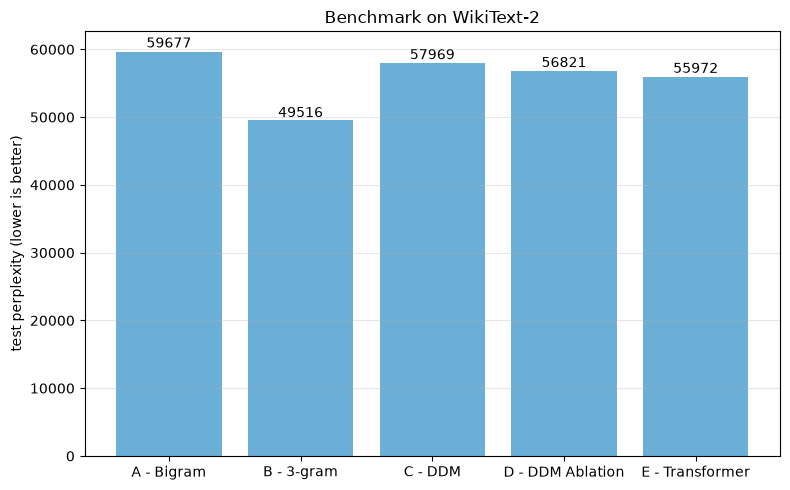

In [7]:
names = list(all_results)
ppl = [all_results[n]["test_ppl_mean"] for n in names]
plt.figure(figsize=(8, 5))
bars = plt.bar(names, ppl, color=["#6baed6"] * len(names))
for b, v in zip(bars, ppl, strict=True):
    plt.text(b.get_x() + b.get_width() / 2, v * 1.01, f"{v:.0f}", ha="center")
plt.ylabel("test perplexity (lower is better)"); plt.title("Benchmark on WikiText-2")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

### How to read the results

- **Bigram / 3-gram** only use the last 1 / 3 tokens: they set the floor.
- **DDM vs DDM-Ablation** isolates the contribution of *learning* the
  distance curve (both share ALiBi penalties + segment memory).
- **DDM vs Transformer** compares the distance-aware inductive bias against
  a standard decoder-only transformer at equal parameter count.
- **PPL(0-10) vs PPL(50-200)**: a drop at late positions shows the model
  benefits from longer context (the memory token + distance penalty).